# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas as pd
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion parameter values
Discretizations= np.loadtxt(
    "../DATA_reaction/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA_reaction/diffusion.txt"
).astype(
    int
)

In [8]:
Discretizations

46

In [9]:
Discretizations=np.array([Discretizations])

In [10]:
diffusion=np.array([diffusion[2]])
print(diffusion)

[75]


In [11]:
# introduction of the high fidelity part of the dataset
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

# I consider only the reaction term as a variable
U_HF_test = U_HF_test[:, -1, 44,44]
# normalization of the data
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test=normalization(U_HF_test)

# transformation of the dataseet
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [12]:
# data augmentation introducing a noise
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

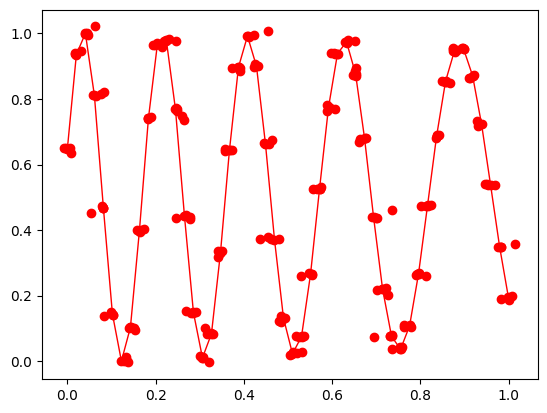

In [13]:
# plot of the new dataset
plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")
plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, "r-", linewidth=1, label="HF model")
plt.show()

In [14]:
# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([100])
Nlf = np.array([200])
n_per=np.array([150])
batch_size=[200,150, 100]


In [15]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[7000,1500,8000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pd.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pd.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores LF R^2
r2_Lin_df = pd.DataFrame(columns=['Discretization','Diffusion','R2'])
mse_HF_df = pd.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pd.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores LF MSE
mse_Lin_df = pd.DataFrame(columns=['Discretization','Diffusion','MSE'])

## Neural Network
Cycle on the Discretization and the value of the diffusion 

Folder '3_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 137.797396 seconds.


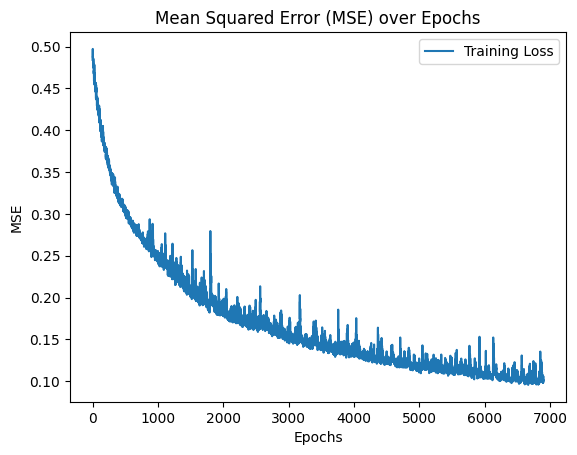

The function training took 29.372125 seconds.


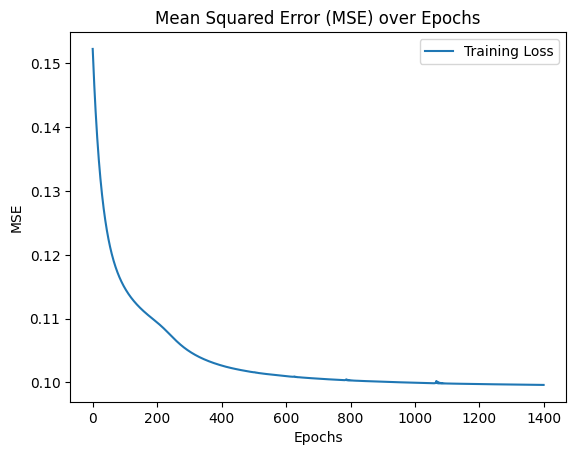

The function training took 148.017804 seconds.


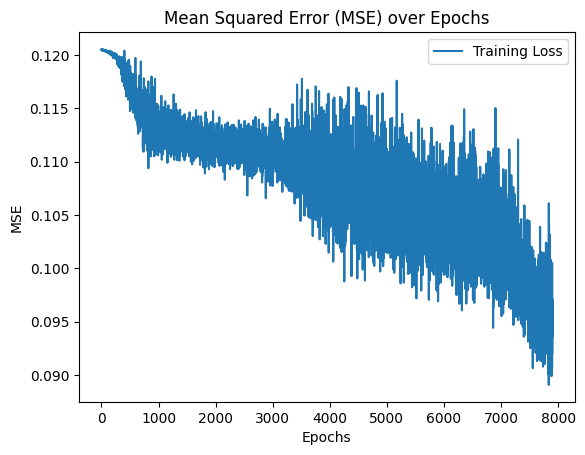

low fidelity NN
Test MSE: 0.01729800962633972
R^2: 0.8611518093358006


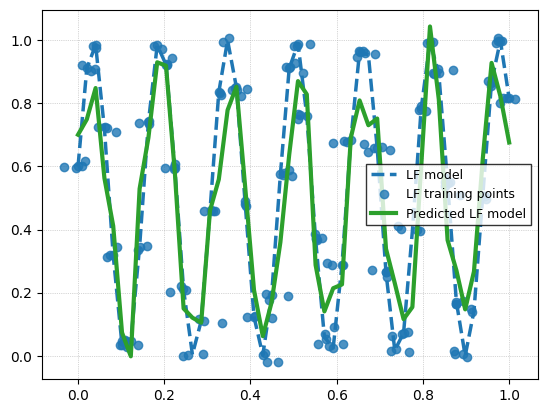

second model
Test MSE: 0.10449225348553912
R^2: 0.07691366436556901
Test MSE: 0.08121324096962805
R^2: 0.28256085488648397


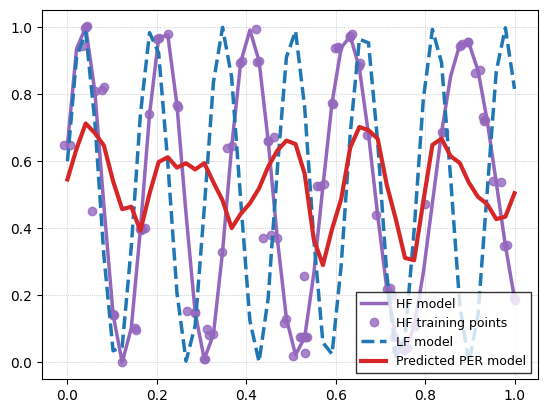

third model
Test MSE: 0.08121324096962805
R^2: 0.28256085488648397


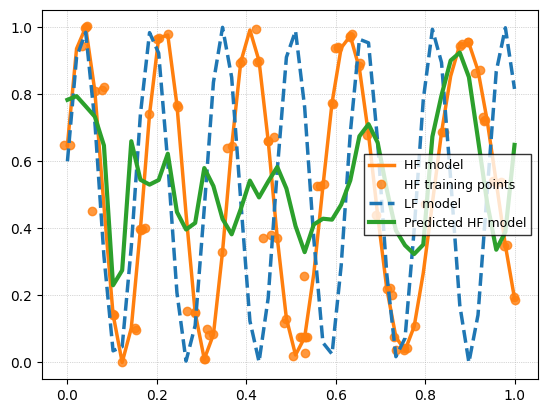

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21664\3294530816.py:278: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21664\3294530816.py:281: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21664\3294530816.py:284: FutureWarning: The behavior of DataFrame concaten

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 148.048589 seconds.


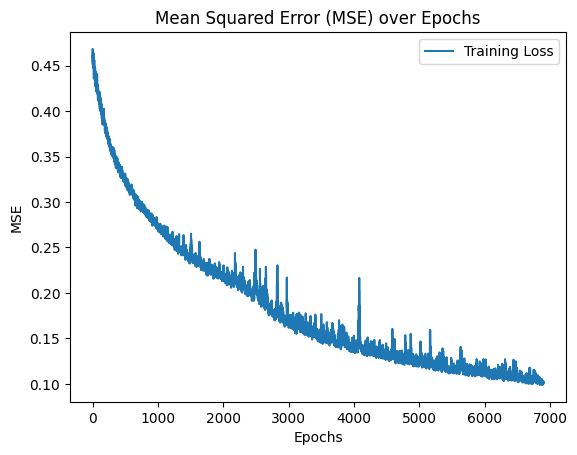

The function training took 29.259023 seconds.


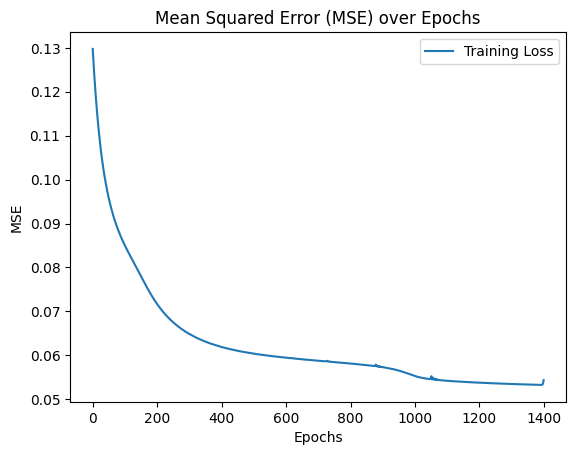

The function training took 151.999921 seconds.


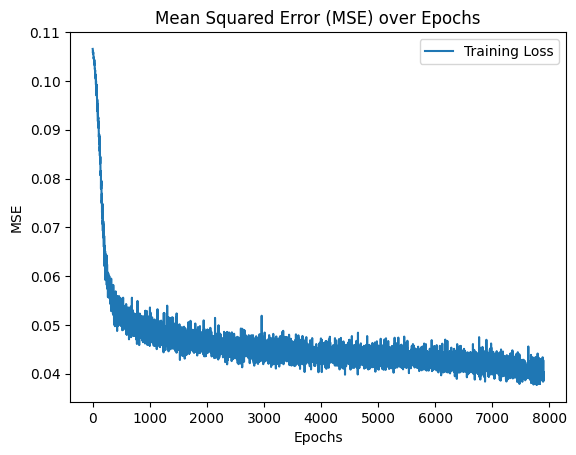

low fidelity NN
Test MSE: 0.01254792714609841
R^2: 0.889699822389579


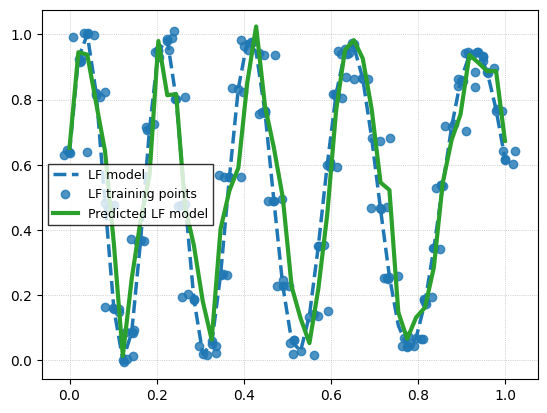

second model
Test MSE: 0.03946530560196311
R^2: 0.6513628224330457
Test MSE: 0.036608332102756935
R^2: 0.6766013746741635


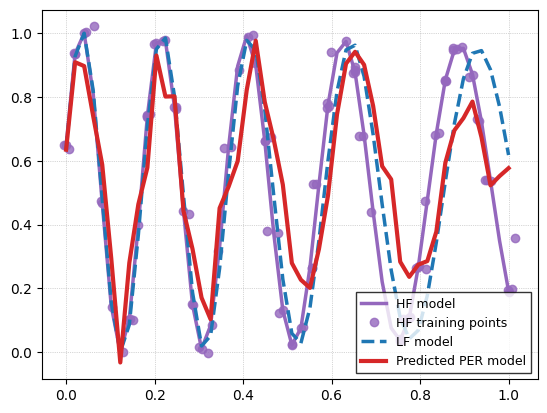

third model
Test MSE: 0.036608332102756935
R^2: 0.6766013746741635


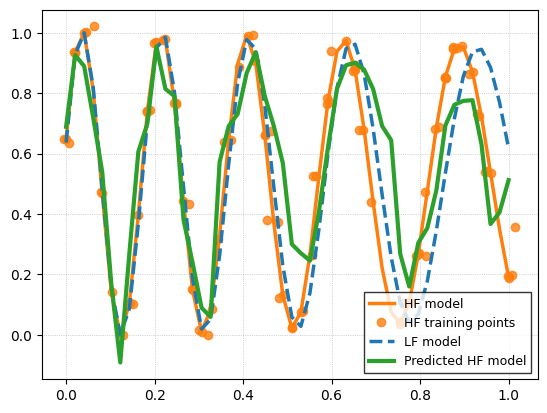

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 141.095319 seconds.


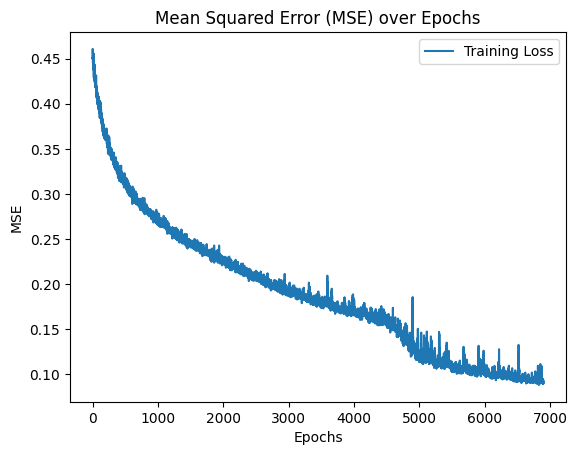

The function training took 29.869223 seconds.


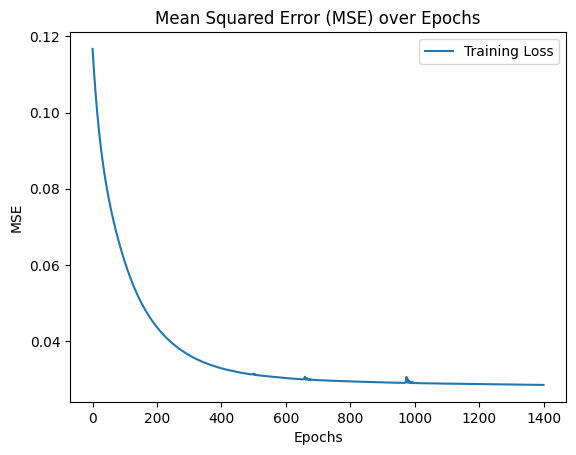

The function training took 152.132101 seconds.


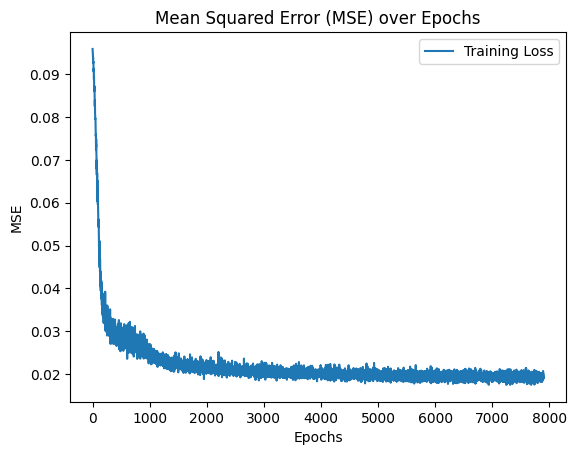

low fidelity NN
Test MSE: 0.00907281564630991
R^2: 0.9229734767971506


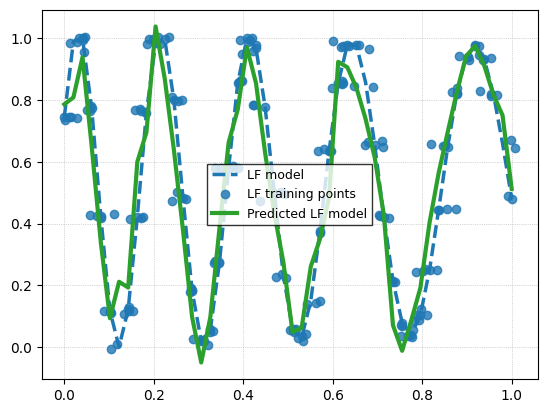

second model
Test MSE: 0.016793200106671645
R^2: 0.8516485860629989
Test MSE: 0.01476864513502627
R^2: 0.8695335389444603


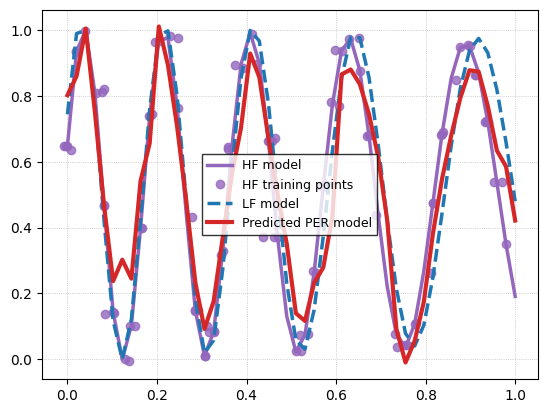

third model
Test MSE: 0.01476864513502627
R^2: 0.8695335389444603


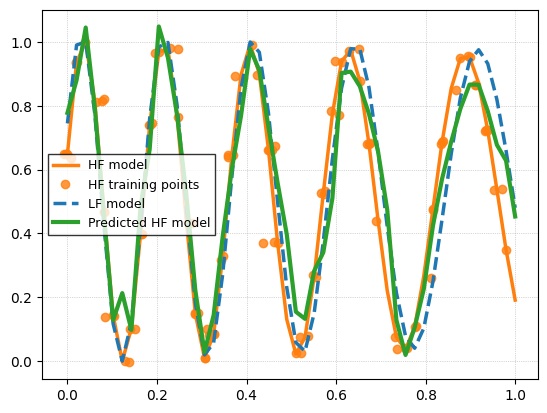

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************


KeyboardInterrupt: 

In [ ]:
# Name of the folder
folder_name = "3_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []
    test_mse_per_list = []

    r2_HF_list = []
    r2_LF_list = []
    r2_per_list = []

    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                for nper in n_per:
        
                    print(
                    f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                    )
                    
                    print(
                    f"********************  # Diff: = {diffusion[d]}  ********************"
                    )
                    
                    print(
                    f"********************  # NHF: = {nhf}  ********************"
                    )
                    print(
                    f"********************  # Nper: = {nper}  ********************"
                    )

                    print(
                    f"********************  # NLF: = {nlf}  ********************"
                    )

                    
                    ### import of the Low Fidelity component of the dataset 
                    file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                    (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                    # selection and normalization of the dataset
                    U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
                    U_LF_test = normalization(U_LF_test)
                    reaction_LF_test = normalization(reaction_LF_test)
                    
                    # transformation of the Low fidelity test set
                    reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
                    
                    # dataset augmentation adding a noise
                    noise_std1=[0.02,0.01,0.02,0.01]
                    noise_std2=[0.01,0.005,0.01,0.005]
                    (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                    
                    # randomization and selection of the training set

                    permutation = np.random.permutation(len(reaction_LF_test))
                    reaction_LF = reaction_LF_test[permutation][0:nlf]
                    U_train_LF = U_LF_test[permutation][0:nlf]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_per = reaction_HF_test[permutation,:][0:nper,:]
                    U_train_per = U_HF_test[permutation][0:nper]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                    U_HF = U_HF_test[permutation][0:nhf]


                    # transformation of the dataset
                    reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                    reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    
                    ##########################      Neural Network     ##########################
                    K.clear_session()
                    
                    # parameters 
                    bestLF_params = {
                        "lr": 0.0255,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                    } 
                    bestper_params = {
                        "lr": 0.002,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                        "l2weight": 0.01,
                    }
                    best_params={'kernel_init': 'uniform', 
                                'l2weight': 0.005395541657336886, 
                                'lr': 0.0025412188591473228, 
                                'nodes': 12.0, 
                                'opt': 'Adamax'}


                    # Multifidelity network 
                    names=["LF","Hfper","HF"]
                    params=[bestLF_params, bestper_params, best_params]
                    data_train=[reaction_LF, reaction_per,reaction_HF]
                    output_train=[U_train_LF, U_train_per, U_HF]

                    definition_3steps = {
                                        "network_type": "2step",
                                        "names": names,
                                        "params": params,
                                        "data_train": data_train,
                                        "output_train": output_train,
                                        "N": Nepo,
                                        "n": batch_size,
                                        "train": True,
                                        "do_HPO": False,
                                        "verbose": False
                                        }
                    model= NetworkFactory.build_network(**definition_3steps)
    

    ### Network 1
                    ULF = model.model_list[0].prediction(reaction_LF_test_original)
                    print("low fidelity NN")
                    
                    (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                    test_mse_LF_list.append(test_mse_LF)
                    r2_LF_list.append(r2_LF)

    ### Plot Network 1

                    plt.figure()

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        reaction_LF[:, 0],
                        U_train_LF,
                        "o",
                        markersize=6,
                        color="#1F77B4",
                        alpha=0.8,
                        label="LF training points",
                    )

                    plt.plot(
                        reaction_LF_test_original[:, 0],
                        model.model_list[0].prediction(reaction_LF_test_original),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted LF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()

    ### Network 2

                    input_per = np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    )  # <- TRAINING INPUT for the second NN: NN_HF

                    input_per_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    print("second model")
                    (test_mse_per,r2_per) = model.model_list[1].performance(input_per,U_HF_test_original)
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)


                    (test_mse_per,r2_per) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)
                    
    ### Plot Network 2


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#9467BD", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_per_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#9467BD",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_per[:, 0],
                        model.model_list[1].prediction(input_per),
                        color="#D62728",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted PER model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()



                    # plots of the model
    ### Network 3
                    input_HF=np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    ) 

                    input_HF=np.concatenate((input_HF, model.model_list[1].prediction(input_HF).reshape(-1,1)),axis=1)


                    input_HF_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    input_HF_train=np.concatenate((input_HF_train, model.model_list[1].prediction(input_HF_train).reshape(-1,1)),axis=1)


                    print("third model")
                    (test_mse_HF,r2_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_HF_list.append(test_mse_HF)
                    r2_HF_list.append(r2_HF)
                    
    ### Plot Network 3


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_HF_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#FF7F0E",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_HF[:, 0],
                        model.model_list[2].prediction(input_HF),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted HF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()


                    

                    
                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                    r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                    r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                    mse_LF_df = pd.concat([mse_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                    mse_HF_df = pd.concat([mse_HF_df, pd.DataFrame([new])], ignore_index=True)
                
                
                    # # save the model
                    # if not r2_HF_list[:-1]:
                    #     model.save(str(Discretizations[m]),folder_path)
                    # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                    #     model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

Folder '3_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************


[I 2024-08-15 12:42:15,057] A new study created in memory with name: no-name-e3c6618f-9858-4722-ab61-fbb4462dc847
[I 2024-08-15 12:44:44,382] Trial 0 finished with value: 0.07492202030171333 and parameters: {'nodes': 13, 'l2weight': 0.006560890044989014, 'lr': 0.00763517658469449, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.07492202030171333.
[I 2024-08-15 12:47:17,787] Trial 1 finished with value: 0.12868067264455618 and parameters: {'nodes': 7, 'l2weight': 0.0006842389824501549, 'lr': 0.0034630412753161224, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.07492202030171333.
[I 2024-08-15 12:49:55,710] Trial 2 finished with value: 0.05674653811240941 and parameters: {'nodes': 4, 'l2weight': 0.0008908698066317102, 'lr': 0.022419103896217894, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 2 with value: 0.05674653811240941.
[I 2024-08-15 12:52:33,719] Trial 3 finished with value: 0.11276433370595874 and 

The function training took 139.987949 seconds.


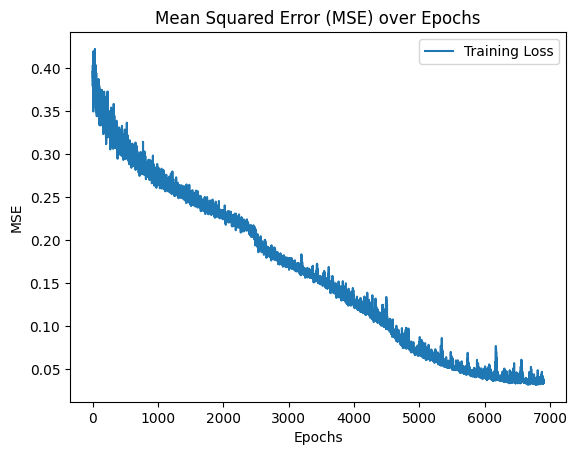

[I 2024-08-15 12:57:33,564] A new study created in memory with name: no-name-d0d390ee-fe4b-4606-9d90-8b63d4cd03f4
[I 2024-08-15 12:58:12,867] Trial 0 finished with value: 0.02460856215963498 and parameters: {'nodes': 9, 'l2weight': 0.005484729091178437, 'lr': 0.052963487324388055, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.02460856215963498.
[I 2024-08-15 12:58:46,466] Trial 1 finished with value: 0.023631915222714364 and parameters: {'nodes': 28, 'l2weight': 0.008200164846709365, 'lr': 0.05153376649206307, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.023631915222714364.
[I 2024-08-15 12:59:23,759] Trial 2 finished with value: 0.11368976968282693 and parameters: {'nodes': 22, 'l2weight': 0.08554540714654389, 'lr': 0.03125883763129905, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 1 with value: 0.023631915222714364.
[I 2024-08-15 13:00:00,560] Trial 3 finished with value: 0.019431322087939407 and pa

The function training took 28.967681 seconds.


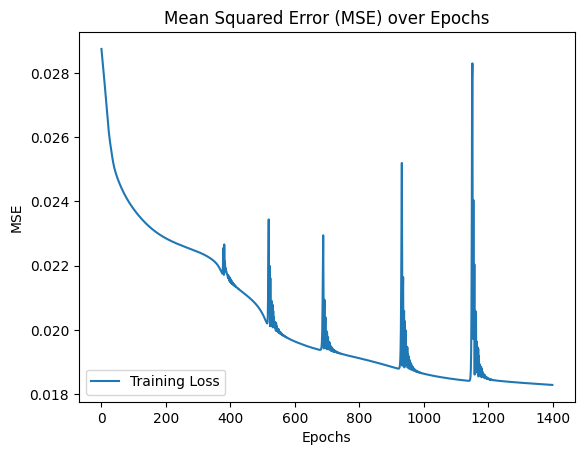

[I 2024-08-15 13:01:07,777] A new study created in memory with name: no-name-2e53872c-eba6-4845-ba0f-a5448339554b
[I 2024-08-15 13:04:07,336] Trial 0 finished with value: 0.02246839919320241 and parameters: {'nodes': 12, 'l2weight': 0.008932622739761708, 'lr': 0.006478739574646008, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.02246839919320241.
[I 2024-08-15 13:07:00,859] Trial 1 finished with value: 0.02322323288076587 and parameters: {'nodes': 18, 'l2weight': 0.0011998605677092965, 'lr': 0.00011676585085643735, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.02246839919320241.
[I 2024-08-15 13:09:54,324] Trial 2 finished with value: 0.02295075644675188 and parameters: {'nodes': 4, 'l2weight': 0.012995075978536975, 'lr': 0.0003642558939553106, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.02246839919320241.
[I 2024-08-15 13:12:59,169] Trial 3 finished with value: 0.022313575088144896 

The function training took 154.031057 seconds.


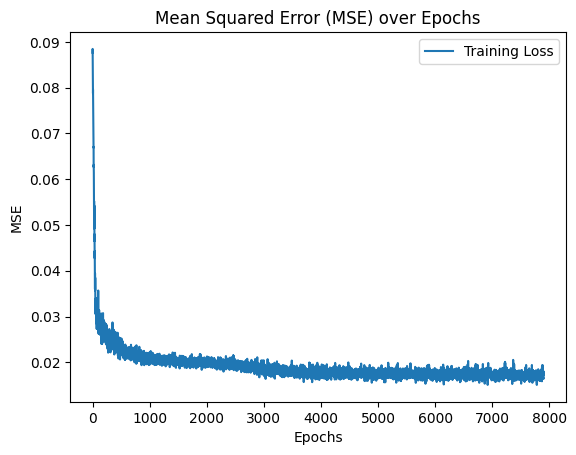

low fidelity NN
Test MSE: 0.005420262621543076
R^2: 0.9539829749815723


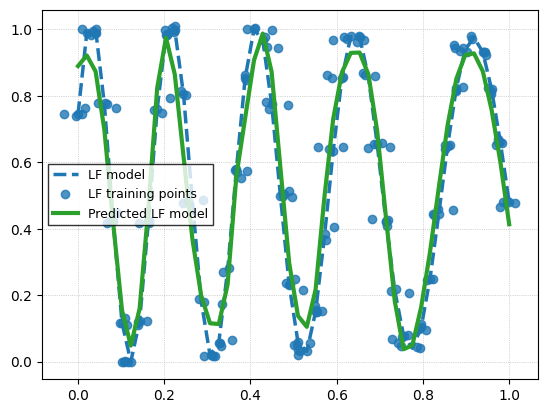

second model
Test MSE: 0.008638632325388862
R^2: 0.9236861758442226
Test MSE: 0.007995016922292389
R^2: 0.9293718852072083


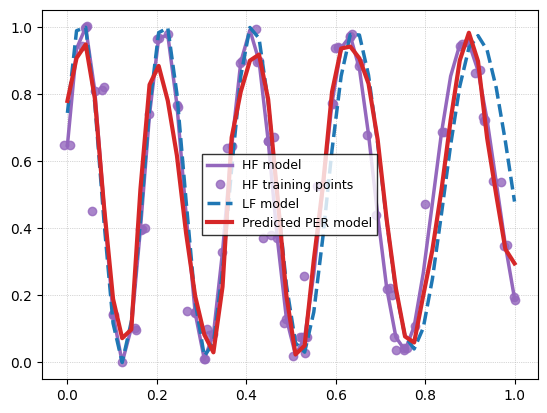

third model
Test MSE: 0.007995016922292389
R^2: 0.9293718852072083


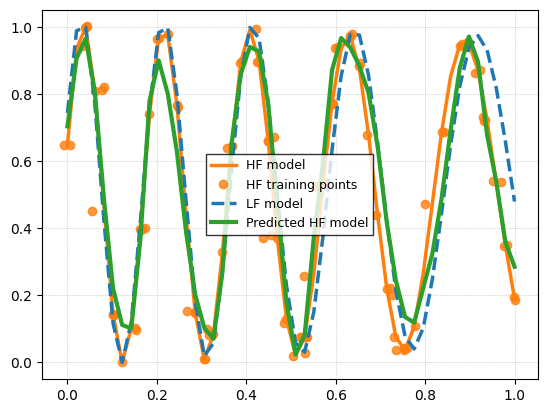

  Discretization Diffusion       R2  diffusion
0             46       NaN  0.92937       75.0
  Discretization Diffusion    MSE  diffusion
0             46       NaN  0.008       75.0


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_1368\1222044636.py:278: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_1368\1222044636.py:281: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_1368\1222044636.py:284: FutureWarning: The behavior of DataFrame concatenati

In [16]:
# Name of the folder
folder_name = "3_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []
    test_mse_per_list = []

    r2_HF_list = []
    r2_LF_list = []
    r2_per_list = []

    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                for nper in n_per:
        
                    print(
                    f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                    )
                    
                    print(
                    f"********************  # Diff: = {diffusion[d]}  ********************"
                    )
                    
                    print(
                    f"********************  # NHF: = {nhf}  ********************"
                    )
                    print(
                    f"********************  # Nper: = {nper}  ********************"
                    )

                    print(
                    f"********************  # NLF: = {nlf}  ********************"
                    )

                    
                    ### import of the Low Fidelity component of the dataset 
                    file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                    (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                    # selection and normalization of the dataset
                    U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
                    U_LF_test = normalization(U_LF_test)
                    reaction_LF_test = normalization(reaction_LF_test)
                    
                    # transformation of the Low fidelity test set
                    reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
                    
                    # dataset augmentation adding a noise
                    noise_std1=[0.02,0.01,0.02,0.01]
                    noise_std2=[0.01,0.005,0.01,0.005]
                    (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                    
                    # randomization and selection of the training set

                    permutation = np.random.permutation(len(reaction_LF_test))
                    reaction_LF = reaction_LF_test[permutation][0:nlf]
                    U_train_LF = U_LF_test[permutation][0:nlf]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_per = reaction_HF_test[permutation,:][0:nper,:]
                    U_train_per = U_HF_test[permutation][0:nper]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                    U_HF = U_HF_test[permutation][0:nhf]


                    # transformation of the dataset
                    reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                    reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    
                    ##########################      Neural Network     ##########################
                    K.clear_session()
                    
                    # parameters 
                    bestLF_params = {
                        "lr": 0.0255,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                    } 
                    bestper_params = {
                        "lr": 0.002,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                        "l2weight": 0.01,
                    }
                    best_params={'kernel_init': 'uniform', 
                                'l2weight': 0.005395541657336886, 
                                'lr': 0.0025412188591473228, 
                                'nodes': 12.0, 
                                'opt': 'Adamax'}


                    # Multifidelity network 
                    names=["LF","Hfper","HF"]
                    params=[bestLF_params, bestper_params, best_params]
                    data_train=[reaction_LF, reaction_per,reaction_HF]
                    output_train=[U_train_LF, U_train_per, U_HF]

                    definition_3steps = {
                                        "network_type": "2step",
                                        "names": names,
                                        "params": params,
                                        "data_train": data_train,
                                        "output_train": output_train,
                                        "N": Nepo,
                                        "n": batch_size,
                                        "train": True,
                                        "do_HPO": True,
                                        "verbose": False
                                        }
                    model= NetworkFactory.build_network(**definition_3steps)
    

    ### Network 1
                    ULF = model.model_list[0].prediction(reaction_LF_test_original)
                    print("low fidelity NN")
                    
                    (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                    test_mse_LF_list.append(test_mse_LF)
                    r2_LF_list.append(r2_LF)

    ### Plot Network 1

                    plt.figure()

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        reaction_LF[:, 0],
                        U_train_LF,
                        "o",
                        markersize=6,
                        color="#1F77B4",
                        alpha=0.8,
                        label="LF training points",
                    )

                    plt.plot(
                        reaction_LF_test_original[:, 0],
                        model.model_list[0].prediction(reaction_LF_test_original),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted LF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()

    ### Network 2

                    input_per = np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    )  # <- TRAINING INPUT for the second NN: NN_HF

                    input_per_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    print("second model")
                    (test_mse_per,r2_per) = model.model_list[1].performance(input_per,U_HF_test_original)
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)


                    (test_mse_per,r2_per) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)
                    
    ### Plot Network 2


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#9467BD", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_per_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#9467BD",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_per[:, 0],
                        model.model_list[1].prediction(input_per),
                        color="#D62728",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted PER model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()



                    # plots of the model
    ### Network 3
                    input_HF=np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    ) 

                    input_HF=np.concatenate((input_HF, model.model_list[1].prediction(input_HF).reshape(-1,1)),axis=1)


                    input_HF_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    input_HF_train=np.concatenate((input_HF_train, model.model_list[1].prediction(input_HF_train).reshape(-1,1)),axis=1)


                    print("third model")
                    (test_mse_HF,r2_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_HF_list.append(test_mse_HF)
                    r2_HF_list.append(r2_HF)
                    
    ### Plot Network 3


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_HF_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#FF7F0E",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_HF[:, 0],
                        model.model_list[2].prediction(input_HF),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted HF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()


                    

                    
                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                    r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                    r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                    mse_LF_df = pd.concat([mse_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                    mse_HF_df = pd.concat([mse_HF_df, pd.DataFrame([new])], ignore_index=True)
                
                
                    # # save the model
                    # if not r2_HF_list[:-1]:
                    #     model.save(str(Discretizations[m]),folder_path)
                    # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                    #     model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

Folder '3_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 1.372909 seconds.


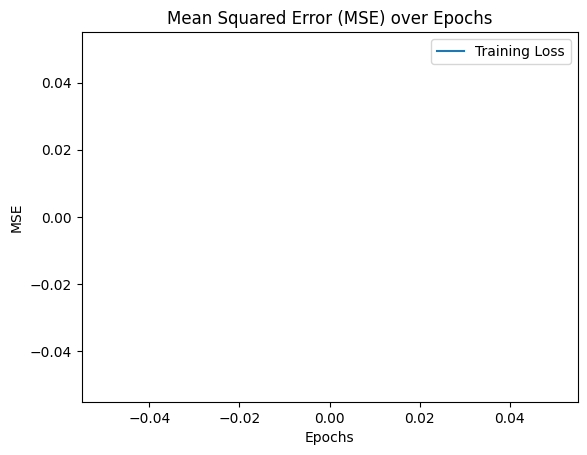

ValueError: Exception encountered when calling Functional.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 64, but received input with shape (150, 3)[0m

Arguments received by Functional.call():
  • inputs=tf.Tensor(shape=(150, 3), dtype=float32)
  • training=True
  • mask=None

In [9]:
# Name of the folder
folder_name = "3_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []
    test_mse_per_list = []

    r2_HF_list = []
    r2_LF_list = []
    r2_per_list = []

    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                for nper in n_per:
        
                    print(
                    f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                    )
                    
                    print(
                    f"********************  # Diff: = {diffusion[d]}  ********************"
                    )
                    
                    print(
                    f"********************  # NHF: = {nhf}  ********************"
                    )
                    print(
                    f"********************  # Nper: = {nper}  ********************"
                    )

                    print(
                    f"********************  # NLF: = {nlf}  ********************"
                    )

                    
                    ### import of the Low Fidelity component of the dataset 
                    file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                    (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                    # selection and normalization of the dataset
                    U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
                    U_LF_test = normalization(U_LF_test)
                    reaction_LF_test = normalization(reaction_LF_test)
                    
                    # transformation of the Low fidelity test set
                    reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
                    
                    # dataset augmentation adding a noise
                    noise_std1=[0.02,0.01,0.02,0.01]
                    noise_std2=[0.01,0.005,0.01,0.005]
                    (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                    
                    # randomization and selection of the training set

                    permutation = np.random.permutation(len(reaction_LF_test))
                    reaction_LF = reaction_LF_test[permutation][0:nlf]
                    U_train_LF = U_LF_test[permutation][0:nlf]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_per = reaction_HF_test[permutation,:][0:nper,:]
                    U_train_per = U_HF_test[permutation][0:nper]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                    U_HF = U_HF_test[permutation][0:nhf]


                    # transformation of the dataset
                    reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                    reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    
                    ##########################      Neural Network     ##########################
                    K.clear_session()
                    
                    # parameters 
                    bestLF_params = {
                        "lr": 0.0255,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                    } 
                    bestper_params = {
                        "lr": 0.002,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                        "l2weight": 0.01,
                    }
                    best_params={'kernel_init': 'uniform', 
                                'l2weight': 0.005395541657336886, 
                                'lr': 0.0025412188591473228, 
                                'nodes': 12.0, 
                                'opt': 'Adamax'}


                    # Multifidelity network 
                    names=["LF","Hfper","HF"]
                    params=[bestLF_params, bestper_params, best_params]
                    data_train=[reaction_LF, reaction_per,reaction_HF]
                    output_train=[U_train_LF, U_train_per, U_HF]

                    definition_3steps = {
                                        "network_type": "2step",
                                        "names": names,
                                        "params": params,
                                        "data_train": data_train,
                                        "output_train": output_train,
                                        "N": Nepo,
                                        "n": batch_size,
                                        "train": True,
                                        "do_HPO": False,
                                        "verbose": False
                                        }
                    model= NetworkFactory.build_network(**definition_3steps)
    

    ### Network 1
                    ULF = model.model_list[0].prediction(reaction_LF_test_original)
                    print("low fidelity NN")
                    
                    (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                    test_mse_LF_list.append(test_mse_LF)
                    r2_LF_list.append(r2_LF)

    ### Plot Network 1

                    plt.figure()

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        reaction_LF[:, 0],
                        U_train_LF,
                        "o",
                        markersize=6,
                        color="#1F77B4",
                        alpha=0.8,
                        label="LF training points",
                    )

                    plt.plot(
                        reaction_LF_test_original[:, 0],
                        model.model_list[0].prediction(reaction_LF_test_original),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted LF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()

    ### Network 2

                    input_per = np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    )  # <- TRAINING INPUT for the second NN: NN_HF

                    input_per_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    print("second model")
                    (test_mse_per,r2_per) = model.model_list[1].performance(input_per,U_HF_test_original)
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)


                    (test_mse_per,r2_per) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)
                    
    ### Plot Network 2


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#9467BD", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_per_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#9467BD",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_per[:, 0],
                        model.model_list[1].prediction(input_per),
                        color="#D62728",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted PER model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()



                    # plots of the model
    ### Network 3
                    input_HF=np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    ) 

                    input_HF=np.concatenate((input_HF, model.model_list[1].prediction(input_HF).reshape(-1,1)),axis=1)


                    input_HF_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    input_HF_train=np.concatenate((input_HF_train, model.model_list[1].prediction(input_HF_train).reshape(-1,1)),axis=1)


                    print("third model")
                    (test_mse_HF,r2_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_HF_list.append(test_mse_HF)
                    r2_HF_list.append(r2_HF)
                    
    ### Plot Network 3


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_HF_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#FF7F0E",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_HF[:, 0],
                        model.model_list[2].prediction(input_HF),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted HF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()


                    

                    
                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                    r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                    r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                    mse_LF_df = pd.concat([mse_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                    mse_HF_df = pd.concat([mse_HF_df, pd.DataFrame([new])], ignore_index=True)
                
                
                    # # save the model
                    # if not r2_HF_list[:-1]:
                    #     model.save(str(Discretizations[m]),folder_path)
                    # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                    #     model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [ ]:
os.makedirs("MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class")

r2_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class'